# Parameter-Matched Control Experiments: Isolating PRMP's Predict-Subtract Mechanism

This notebook demonstrates **parameter-matched control experiments** that isolate whether PRMP's (Predictive Residual Message Passing) improvement comes from its **predict-subtract mechanism** or merely from having more parameters.

**What it does:**
- Builds a heterogeneous graph from Amazon Video Games review data (reviews ↔ products ↔ customers)
- Trains 5 GNN variants with matched parameter counts:
  - **(A) Standard SAGEConv** — baseline mean aggregation
  - **(B) PRMP** — predict child from parent, subtract prediction, aggregate residuals
  - **(C) Wide SAGEConv** — wider hidden dim to match PRMP's parameter count
  - **(D) Auxiliary MLP** — extra MLP transforms features before aggregation (same params, no subtraction)
  - **(E) Skip-Residual** — standard aggregation + parent skip connection
- Compares RMSE/MAE/R² across seeds with Cohen's d effect sizes

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# Packages NOT pre-installed on Colab (always install everywhere)
_pip('loguru==0.7.3', 'psutil==7.0.0')

# Core packages (pre-installed on Colab, install locally to match Colab env)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2')
    _pip('matplotlib==3.9.4')
    _pip('torch==2.5.1+cpu', '--index-url', 'https://download.pytorch.org/whl/cpu')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import gc
import json
import math
import os
import sys
import time
from collections import defaultdict
from copy import deepcopy

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-outputs/ai-invention-b2d5b0-predictive-residual-message-passing-filt/main/experiment_iter4_parameter_match/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
examples = data['datasets'][0]['examples']
print(f"Loaded {len(examples)} Amazon Video Games review examples")
print(f"Folds: {sorted(set(e['metadata_fold'] for e in examples))}")
print(f"Unique products: {len(set(e['metadata_product_id'] for e in examples))}")
print(f"Unique customers: {len(set(e['metadata_customer_id'] for e in examples))}")

Loaded 80 Amazon Video Games review examples
Folds: [0, 1, 2, 3, 4]
Unique products: 79
Unique customers: 80


## Configuration

All tunable parameters for the experiment. Values are set for a quick demo run; original paper values are noted in comments.

In [5]:
# ── Tunable Parameters ──
HIDDEN_DIM = 128         # Original: 128
NUM_LAYERS = 2           # Original: 2
LEARNING_RATE = 1e-3     # Original: 1e-3
WEIGHT_DECAY = 1e-4      # Original: 1e-4
MAX_EPOCHS = 80          # Original: 80
PATIENCE = 15            # Original: 15
SEEDS = [42, 123, 456]   # Original: [42, 123, 456]
GRAD_CLIP = 5.0          # Original: 5.0

# Feature dimensions from Amazon data
REVIEW_FEAT_DIM = 21
PARENT_FEAT_DIM = 5

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}, Hidden dim: {HIDDEN_DIM}, Epochs: {MAX_EPOCHS}, Seeds: {SEEDS}")

Device: cpu, Hidden dim: 128, Epochs: 80, Seeds: [42, 123, 456]


## Scatter Operations & GNN Convolution Modules

Manual scatter-mean aggregation (no PyG dependency) and 5 convolution variants:
- **StandardConv**: mean-aggregate neighbors, concat with self, linear
- **PRMPConv**: predict child from parent, subtract, normalize residual, aggregate
- **WideStandardConv**: same as Standard but wider to match PRMP params
- **AuxMLPConv**: extra MLP transforms child features before aggregation (no subtraction)
- **SkipResidualConv**: standard aggregation + parent skip connection

In [6]:
def scatter_mean(src: torch.Tensor, index: torch.Tensor, dim_size: int) -> torch.Tensor:
    """Mean aggregation: group src rows by index, compute mean per group."""
    out = torch.zeros(dim_size, src.size(-1), device=src.device, dtype=src.dtype)
    idx = index.unsqueeze(-1).expand_as(src)
    out.scatter_add_(0, idx, src)
    count = torch.zeros(dim_size, 1, device=src.device, dtype=src.dtype)
    ones = torch.ones(index.size(0), 1, device=src.device, dtype=src.dtype)
    count.scatter_add_(0, index.unsqueeze(-1), ones)
    count = count.clamp(min=1)
    return out / count


class StandardConv(nn.Module):
    """(A) Standard SAGEConv-like: mean-aggregate neighbor features, concat with self, linear."""
    def __init__(self, in_src: int, in_dst: int, out_channels: int):
        super().__init__()
        self.lin = nn.Linear(in_src + in_dst, out_channels)

    def forward(self, x_src, x_dst, edge_index):
        src_idx, dst_idx = edge_index[0], edge_index[1]
        x_j = x_src[src_idx]
        agg = scatter_mean(x_j, dst_idx, dim_size=x_dst.size(0))
        return F.relu(self.lin(torch.cat([x_dst, agg], dim=-1)))


class PRMPConv(nn.Module):
    """(B) Predictive Residual Message Passing convolution.
    Predict child from parent, subtract, normalize residual, aggregate."""
    def __init__(self, in_src: int, in_dst: int, out_channels: int):
        super().__init__()
        hidden = min(in_src, in_dst)
        self.pred_mlp = nn.Sequential(
            nn.Linear(in_dst, hidden), nn.ReLU(), nn.Linear(hidden, in_src))
        nn.init.zeros_(self.pred_mlp[-1].weight)
        nn.init.zeros_(self.pred_mlp[-1].bias)
        self.norm = nn.LayerNorm(in_src)
        self.lin = nn.Linear(in_src + in_dst, out_channels)

    def forward(self, x_src, x_dst, edge_index):
        src_idx, dst_idx = edge_index[0], edge_index[1]
        x_j = x_src[src_idx]
        x_i = x_dst[dst_idx]
        predicted = self.pred_mlp(x_i.detach())
        residual = x_j - predicted
        normalized = self.norm(residual)
        agg = scatter_mean(normalized, dst_idx, dim_size=x_dst.size(0))
        return F.relu(self.lin(torch.cat([x_dst, agg], dim=-1)))


class WideStandardConv(nn.Module):
    """(C) Same as StandardConv, but wider hidden dim to match PRMP's param count."""
    def __init__(self, in_src: int, in_dst: int, out_channels: int):
        super().__init__()
        self.lin = nn.Linear(in_src + in_dst, out_channels)

    def forward(self, x_src, x_dst, edge_index):
        src_idx, dst_idx = edge_index[0], edge_index[1]
        x_j = x_src[src_idx]
        agg = scatter_mean(x_j, dst_idx, dim_size=x_dst.size(0))
        return F.relu(self.lin(torch.cat([x_dst, agg], dim=-1)))


class AuxMLPConv(nn.Module):
    """(D) Standard aggregation + extra MLP that transforms child features BEFORE aggregation."""
    def __init__(self, in_src: int, in_dst: int, out_channels: int):
        super().__init__()
        hidden = min(in_src, in_dst)
        self.child_mlp = nn.Sequential(
            nn.Linear(in_src, hidden), nn.ReLU(), nn.Linear(hidden, in_src))
        self.norm = nn.LayerNorm(in_src)
        self.lin = nn.Linear(in_src + in_dst, out_channels)

    def forward(self, x_src, x_dst, edge_index):
        src_idx, dst_idx = edge_index[0], edge_index[1]
        x_j = x_src[src_idx]
        transformed = self.norm(self.child_mlp(x_j))
        agg = scatter_mean(transformed, dst_idx, dim_size=x_dst.size(0))
        return F.relu(self.lin(torch.cat([x_dst, agg], dim=-1)))


class SkipResidualConv(nn.Module):
    """(E) Standard aggregation + skip connection: concat raw parent features to agg."""
    def __init__(self, in_src: int, in_dst: int, out_channels: int):
        super().__init__()
        self.lin = nn.Linear(in_src + in_dst + in_dst, out_channels)

    def forward(self, x_src, x_dst, edge_index):
        src_idx, dst_idx = edge_index[0], edge_index[1]
        x_j = x_src[src_idx]
        agg = scatter_mean(x_j, dst_idx, dim_size=x_dst.size(0))
        return F.relu(self.lin(torch.cat([x_dst, agg, x_dst], dim=-1)))

print("All 5 convolution modules defined.")

All 5 convolution modules defined.


## Heterogeneous GNN Architecture

The `HeteroConvLayer` applies per-edge-type convolutions and sums outputs per destination node type. `HeteroGNN` stacks these layers with per-node-type input projections and a prediction head.

In [7]:
class HeteroConvLayer(nn.Module):
    """Per-edge-type convolutions, sum outputs per destination node type."""
    def __init__(self, conv_dict: dict):
        super().__init__()
        self.convs = nn.ModuleDict()
        self._edge_types = list(conv_dict.keys())
        for etype, conv in conv_dict.items():
            key = '__'.join(etype)
            self.convs[key] = conv

    def forward(self, x_dict, edge_index_dict):
        out_dict = defaultdict(list)
        for etype in self._edge_types:
            key = '__'.join(etype)
            src_type, _, dst_type = etype
            if etype not in edge_index_dict:
                continue
            edge_index = edge_index_dict[etype]
            conv = self.convs[key]
            out = conv(x_dict[src_type], x_dict[dst_type], edge_index)
            out_dict[dst_type].append(out)
        result = {}
        for ntype, outs in out_dict.items():
            result[ntype] = torch.stack(outs).sum(dim=0)
        for ntype in x_dict:
            if ntype not in result:
                result[ntype] = x_dict[ntype]
        return result


class HeteroGNN(nn.Module):
    """Heterogeneous GNN with per-node-type projections + prediction head."""
    def __init__(self, node_types_with_dims, edge_types, hidden_dim, num_layers,
                 conv_cls, target_node_type):
        super().__init__()
        self.target_node_type = target_node_type
        self.proj = nn.ModuleDict()
        for ntype, feat_dim in node_types_with_dims.items():
            self.proj[ntype] = nn.Linear(feat_dim, hidden_dim)
        self.convs = nn.ModuleList()
        for _ in range(num_layers):
            conv_dict = {}
            for etype in edge_types:
                conv_dict[etype] = conv_cls(hidden_dim, hidden_dim, hidden_dim)
            self.convs.append(HeteroConvLayer(conv_dict))
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, 1))

    def forward(self, x_dict, edge_index_dict):
        h_dict = {}
        for ntype, x in x_dict.items():
            h_dict[ntype] = F.relu(self.proj[ntype](x))
        for conv in self.convs:
            h_dict = conv(h_dict, edge_index_dict)
        return self.head(h_dict[self.target_node_type]).squeeze(-1)


def count_params(model):
    """Count total trainable parameters."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def find_wide_hidden_dim(node_dims, edge_types, target_prmp_params, target_node_type):
    """Binary search for wide_hidden_dim so WideStandardConv matches PRMP param count."""
    lo, hi = HIDDEN_DIM + 1, 400
    best_dim, best_diff = HIDDEN_DIM + 10, float('inf')
    for _ in range(50):
        mid = (lo + hi) // 2
        if mid == lo and lo == hi:
            break
        try:
            model = HeteroGNN(node_dims, edge_types, mid, NUM_LAYERS,
                              WideStandardConv, target_node_type).to('cpu')
            p = count_params(model)
            diff = abs(p - target_prmp_params)
            if diff < best_diff:
                best_diff, best_dim = diff, mid
            if p < target_prmp_params:
                lo = mid + 1
            elif p > target_prmp_params:
                hi = mid - 1
            else:
                del model; return mid
            del model
        except Exception:
            hi = mid - 1
    return best_dim

print("HeteroGNN architecture and helpers defined.")

HeteroGNN architecture and helpers defined.


## Data Parsing & Graph Construction

Parse Amazon review examples into feature arrays and build a heterogeneous graph with three node types (review, product, customer) and four edge types (review↔product, review↔customer).

In [8]:
def parse_amazon_examples(examples):
    """Parse example inputs/outputs into numpy arrays."""
    features_list, targets_list = [], []
    product_ids, customer_ids, folds = [], [], []
    for ex in examples:
        feat_dict = json.loads(ex['input'])
        feat_vals = [float(v) for v in feat_dict.values()]
        features_list.append(feat_vals)
        targets_list.append(float(ex['output']))
        product_ids.append(ex['metadata_product_id'])
        customer_ids.append(ex['metadata_customer_id'])
        folds.append(ex['metadata_fold'])
    features = np.array(features_list, dtype=np.float32)
    targets = np.array(targets_list, dtype=np.float32)
    return features, targets, product_ids, customer_ids, folds


def build_amazon_graph(features, targets, product_ids, customer_ids, folds, device):
    """Build heterogeneous graph tensors for Amazon dataset."""
    num_reviews = len(features)
    unique_products = sorted(set(product_ids))
    unique_customers = sorted(set(customer_ids))
    prod_to_idx = {pid: i for i, pid in enumerate(unique_products)}
    cust_to_idx = {cid: i for i, cid in enumerate(unique_customers)}
    num_products = len(unique_products)
    num_customers = len(unique_customers)

    review_x = torch.tensor(features, dtype=torch.float32)
    review_to_prod_src, review_to_prod_dst = [], []
    review_to_cust_src, review_to_cust_dst = [], []
    prod_reviews = defaultdict(list)
    cust_reviews = defaultdict(list)

    for i in range(num_reviews):
        pid = prod_to_idx[product_ids[i]]
        cid = cust_to_idx[customer_ids[i]]
        review_to_prod_src.append(i); review_to_prod_dst.append(pid)
        review_to_cust_src.append(i); review_to_cust_dst.append(cid)
        prod_reviews[pid].append(i); cust_reviews[cid].append(i)

    # Build product features (5 dims)
    prod_features = np.zeros((num_products, PARENT_FEAT_DIM), dtype=np.float32)
    for pid, rev_idxs in prod_reviews.items():
        revs = features[rev_idxs]; rats = targets[rev_idxs]
        prod_features[pid, 0] = np.mean(rats)
        prod_features[pid, 1] = np.std(rats) if len(rats) > 1 else 0.0
        prod_features[pid, 2] = float(len(rats))
        prod_features[pid, 3] = np.mean(revs[:, 19]) if revs.shape[1] > 19 else 0.0
        prod_features[pid, 4] = np.mean(revs[:, 20]) if revs.shape[1] > 20 else 0.0

    # Build customer features (5 dims)
    cust_features = np.zeros((num_customers, PARENT_FEAT_DIM), dtype=np.float32)
    for cid, rev_idxs in cust_reviews.items():
        revs = features[rev_idxs]; rats = targets[rev_idxs]
        cust_features[cid, 0] = np.mean(rats)
        cust_features[cid, 1] = np.std(rats) if len(rats) > 1 else 0.0
        cust_features[cid, 2] = float(len(rats))
        cust_features[cid, 3] = np.mean(revs[:, 19]) if revs.shape[1] > 19 else 0.0
        cust_features[cid, 4] = np.mean(revs[:, 20]) if revs.shape[1] > 20 else 0.0

    product_x = torch.tensor(prod_features, dtype=torch.float32)
    customer_x = torch.tensor(cust_features, dtype=torch.float32)

    edge_index_dict = {
        ('review', 'belongs_to', 'product'): torch.tensor(
            [review_to_prod_src, review_to_prod_dst], dtype=torch.long),
        ('review', 'written_by', 'customer'): torch.tensor(
            [review_to_cust_src, review_to_cust_dst], dtype=torch.long),
        ('product', 'rev_belongs_to', 'review'): torch.tensor(
            [review_to_prod_dst, review_to_prod_src], dtype=torch.long),
        ('customer', 'rev_written_by', 'review'): torch.tensor(
            [review_to_cust_dst, review_to_cust_src], dtype=torch.long),
    }
    x_dict = {
        'review': review_x.to(device),
        'product': product_x.to(device),
        'customer': customer_x.to(device),
    }
    edge_index_dict = {k: v.to(device) for k, v in edge_index_dict.items()}

    folds_arr = np.array(folds)
    train_mask = torch.tensor(np.isin(folds_arr, [0, 1, 2]), dtype=torch.bool).to(device)
    val_mask = torch.tensor(folds_arr == 3, dtype=torch.bool).to(device)
    test_mask = torch.tensor(folds_arr == 4, dtype=torch.bool).to(device)
    targets_tensor = torch.tensor(targets, dtype=torch.float32).to(device)

    node_dims = {'review': REVIEW_FEAT_DIM, 'product': PARENT_FEAT_DIM,
                 'customer': PARENT_FEAT_DIM}
    print(f"Graph: {num_reviews} reviews, {num_products} products, {num_customers} customers")
    print(f"  Train: {train_mask.sum().item()}, Val: {val_mask.sum().item()}, Test: {test_mask.sum().item()}")
    return (x_dict, edge_index_dict, targets_tensor, train_mask, val_mask,
            test_mask, node_dims, list(edge_index_dict.keys()))


# Parse and build graph
features, targets, product_ids, customer_ids, folds = parse_amazon_examples(examples)
print(f"Features shape: {features.shape}, Targets range: [{targets.min():.1f}, {targets.max():.1f}]")

(x_dict, edge_index_dict, targets_tensor, train_mask, val_mask, test_mask,
 node_dims, edge_types) = build_amazon_graph(
    features, targets, product_ids, customer_ids, folds, DEVICE)

Features shape: (80, 21), Targets range: [0.0, 4.0]
Graph: 80 reviews, 79 products, 80 customers
  Train: 48, Val: 16, Test: 16


## Parameter Counting & Training

First verify parameter counts across variants, then train all 5 models. The `train_and_evaluate_variant` function handles training with early stopping, gradient clipping, and test evaluation per seed.

In [9]:
# ── Parameter Counting ──
print("--- Parameter Counts ---")
std_model = HeteroGNN(node_dims, edge_types, HIDDEN_DIM, NUM_LAYERS, StandardConv, "review").to('cpu')
prmp_model = HeteroGNN(node_dims, edge_types, HIDDEN_DIM, NUM_LAYERS, PRMPConv, "review").to('cpu')
aux_model = HeteroGNN(node_dims, edge_types, HIDDEN_DIM, NUM_LAYERS, AuxMLPConv, "review").to('cpu')
skip_model = HeteroGNN(node_dims, edge_types, HIDDEN_DIM, NUM_LAYERS, SkipResidualConv, "review").to('cpu')

std_params = count_params(std_model)
prmp_params = count_params(prmp_model)
aux_params = count_params(aux_model)
skip_params = count_params(skip_model)

print(f"  Standard:     {std_params:>8,d} params")
print(f"  PRMP:         {prmp_params:>8,d} params")
print(f"  AuxMLP:       {aux_params:>8,d} params (matches PRMP: {aux_params == prmp_params})")
print(f"  SkipResidual: {skip_params:>8,d} params")

del std_model, prmp_model, aux_model, skip_model; gc.collect()

# Find wide hidden dim
wide_dim = find_wide_hidden_dim(node_dims, edge_types, prmp_params, "review")
wide_model = HeteroGNN(node_dims, edge_types, wide_dim, NUM_LAYERS, WideStandardConv, "review").to('cpu')
wide_params = count_params(wide_model)
del wide_model; gc.collect()
print(f"  Wide SAGEConv: {wide_params:>8,d} params (hidden_dim={wide_dim})")
print(f"  Wide vs PRMP diff: {abs(wide_params - prmp_params)} ({abs(wide_params - prmp_params)/prmp_params*100:.1f}%)")

--- Parameter Counts ---
  Standard:      284,161 params
  PRMP:          550,401 params
  AuxMLP:        550,401 params (matches PRMP: True)
  SkipResidual:  415,233 params


  Wide SAGEConv:  552,574 params (hidden_dim=179)


  Wide vs PRMP diff: 2173 (0.4%)


In [10]:
def train_and_evaluate_variant(variant_name, conv_cls, hidden_dim, node_dims,
                               edge_types, target_node_type, x_dict,
                               edge_index_dict, targets, train_mask, val_mask,
                               test_mask, loss_fn, device):
    """Train and evaluate a single variant across all seeds."""
    print(f"\n--- {variant_name} (hidden={hidden_dim}) ---")
    results = {}
    for seed in SEEDS:
        torch.manual_seed(seed)
        np.random.seed(seed)
        model = HeteroGNN(node_dims, edge_types, hidden_dim, NUM_LAYERS,
                          conv_cls, target_node_type).to(device)
        param_count = count_params(model)
        optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE,
                                     weight_decay=WEIGHT_DECAY)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', patience=max(1, PATIENCE // 2), factor=0.5)

        best_val_loss, best_state, patience_counter, best_epoch = float('inf'), None, 0, 0
        t0 = time.time()

        for epoch in range(MAX_EPOCHS):
            model.train()
            optimizer.zero_grad()
            pred = model(x_dict, edge_index_dict)
            loss = loss_fn(pred[train_mask], targets[train_mask])
            if torch.isnan(loss):
                print(f"  {variant_name} seed={seed}: NaN loss at epoch {epoch}")
                break
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP)
            optimizer.step()

            model.eval()
            with torch.no_grad():
                val_pred = model(x_dict, edge_index_dict)
                val_loss = loss_fn(val_pred[val_mask], targets[val_mask])
            scheduler.step(val_loss)

            if val_loss.item() < best_val_loss:
                best_val_loss = val_loss.item()
                best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                patience_counter, best_epoch = 0, epoch + 1
            else:
                patience_counter += 1
                if patience_counter >= PATIENCE:
                    break

        train_time = time.time() - t0
        if best_state is not None:
            model.load_state_dict(best_state)
            model.to(device)
        model.eval()
        with torch.no_grad():
            test_pred = model(x_dict, edge_index_dict)
        pred_np = test_pred[test_mask].cpu().numpy()
        true_np = targets[test_mask].cpu().numpy()

        rmse = float(np.sqrt(np.mean((pred_np - true_np) ** 2)))
        mae = float(np.mean(np.abs(pred_np - true_np)))
        ss_res = float(np.sum((pred_np - true_np) ** 2))
        ss_tot = float(np.sum((true_np - np.mean(true_np)) ** 2))
        r2 = float(1.0 - ss_res / max(ss_tot, 1e-8))

        results[seed] = {
            'rmse': round(rmse, 6), 'mae': round(mae, 6), 'r2': round(r2, 6),
            'param_count': param_count, 'best_epoch': best_epoch,
            'epochs_trained': epoch + 1, 'train_time_s': round(train_time, 1),
        }
        print(f"  seed={seed}: RMSE={rmse:.4f}, MAE={mae:.4f}, R2={r2:.4f}, "
              f"epochs={epoch+1}, params={param_count:,d}, time={train_time:.1f}s")
        del model, optimizer, scheduler, best_state; gc.collect()
    return results

print("Training function defined.")

Training function defined.


In [11]:
# ── Train All 5 Variants ──
t_global = time.time()
loss_fn = nn.MSELoss()
all_results = {}

variants = [
    ("A_standard_sage", StandardConv, HIDDEN_DIM),
    ("B_prmp", PRMPConv, HIDDEN_DIM),
    ("C_wide_sage", WideStandardConv, wide_dim),
    ("D_aux_mlp", AuxMLPConv, HIDDEN_DIM),
    ("E_skip_residual", SkipResidualConv, HIDDEN_DIM),
]

for vname, conv_cls, hdim in variants:
    all_results[vname] = train_and_evaluate_variant(
        variant_name=vname, conv_cls=conv_cls, hidden_dim=hdim,
        node_dims=node_dims, edge_types=edge_types,
        target_node_type="review", x_dict=x_dict,
        edge_index_dict=edge_index_dict, targets=targets_tensor,
        train_mask=train_mask, val_mask=val_mask, test_mask=test_mask,
        loss_fn=loss_fn, device=DEVICE)

total_time = time.time() - t_global
print(f"\nTotal training time: {total_time:.1f}s")


--- A_standard_sage (hidden=128) ---


  seed=42: RMSE=0.0887, MAE=0.0643, R2=0.9841, epochs=80, params=284,161, time=41.3s


  seed=123: RMSE=0.0817, MAE=0.0643, R2=0.9865, epochs=80, params=284,161, time=0.5s


  seed=456: RMSE=0.0795, MAE=0.0686, R2=0.9872, epochs=80, params=284,161, time=0.5s

--- B_prmp (hidden=128) ---


  seed=42: RMSE=0.1721, MAE=0.1039, R2=0.9403, epochs=74, params=550,401, time=0.8s


...

  seed=123: RMSE=0.1880, MAE=0.1219, R2=0.9287, epochs=66, params=550,401, time=0.7s


  seed=456: RMSE=0.1956, MAE=0.1482, R2=0.9229, epochs=54, params=550,401, time=0.6s

--- E_skip_residual (hidden=128) ---


  seed=42: RMSE=0.0909, MAE=0.0642, R2=0.9834, epochs=80, params=415,233, time=0.5s


  seed=123: RMSE=0.0590, MAE=0.0447, R2=0.9930, epochs=80, params=415,233, time=0.5s


  seed=456: RMSE=0.0923, MAE=0.0674, R2=0.9828, epochs=80, params=415,233, time=0.5s

Total training time: 52.7s


## Statistical Analysis

Compute Cohen's d effect sizes comparing PRMP vs each control variant. Cohen's d > 0.8 indicates a large effect; d > 2 is very large.

In [12]:
def compute_cohens_d(group1_values, group2_values):
    """Cohen's d effect size: (mean1 - mean2) / pooled_std."""
    n1, n2 = len(group1_values), len(group2_values)
    if n1 < 2 or n2 < 2:
        return 0.0
    m1, m2 = np.mean(group1_values), np.mean(group2_values)
    s1, s2 = np.std(group1_values, ddof=1), np.std(group2_values, ddof=1)
    pooled_std = math.sqrt(((n1 - 1) * s1 ** 2 + (n2 - 1) * s2 ** 2) / (n1 + n2 - 2))
    return float((m1 - m2) / max(pooled_std, 1e-8))


# Analyze PRMP vs controls
primary_metric = "rmse"
prmp_results = all_results.get("B_prmp", {})
prmp_values = [prmp_results[s][primary_metric] for s in SEEDS if s in prmp_results]

analysis = {}
for variant_name in ["A_standard_sage", "C_wide_sage", "D_aux_mlp", "E_skip_residual"]:
    ctrl = all_results.get(variant_name, {})
    ctrl_values = [ctrl[s][primary_metric] for s in SEEDS if s in ctrl]
    if not ctrl_values or not prmp_values:
        continue
    d = compute_cohens_d(prmp_values, ctrl_values)
    prmp_mean = float(np.mean(prmp_values))
    ctrl_mean = float(np.mean(ctrl_values))
    improvement_pct = (ctrl_mean - prmp_mean) / max(abs(ctrl_mean), 1e-8) * 100
    analysis[f"prmp_vs_{variant_name}"] = {
        "cohens_d": round(d, 4),
        "prmp_mean": round(prmp_mean, 6),
        "control_mean": round(ctrl_mean, 6),
        "improvement_pct": round(improvement_pct, 2),
        "prmp_better": prmp_mean < ctrl_mean,
    }

# Print analysis
print("=== Cohen's d Analysis (PRMP vs Controls) ===")
for key, val in analysis.items():
    status = "PRMP better" if val["prmp_better"] else "Control better"
    print(f"  {key}: d={val['cohens_d']:.4f}, improvement={val['improvement_pct']:.2f}%, {status}")

=== Cohen's d Analysis (PRMP vs Controls) ===
  prmp_vs_A_standard_sage: d=14.2918, improvement=-98.42%, Control better
  prmp_vs_C_wide_sage: d=2.6409, improvement=-93.52%, Control better
  prmp_vs_D_aux_mlp: d=-3.4807, improvement=16.57%, PRMP better
  prmp_vs_E_skip_residual: d=5.9999, improvement=-104.86%, Control better


## Results Visualization

Summary table and bar chart comparing all 5 variants on RMSE, MAE, and R² metrics.

Variant                    Params       RMSE        MAE         R2
------------------------------------------------------------------
A_standard_sage           284,161     0.0887     0.0643     0.9841
A_standard_sage           284,161     0.0817     0.0643     0.9865
A_standard_sage           284,161     0.0795     0.0686     0.9872
B_prmp                    550,401     0.1721     0.1039     0.9403
B_prmp                    550,401     0.1590     0.1218     0.9490
B_prmp                    550,401     0.1649     0.1212     0.9452
C_wide_sage               552,574     0.0497     0.0410     0.9950
C_wide_sage               552,574     0.1321     0.1012     0.9648
C_wide_sage               552,574     0.0745     0.0552     0.9888
D_aux_mlp                 550,401     0.2108     0.1015     0.9104
D_aux_mlp                 550,401     0.1880     0.1219     0.9287
D_aux_mlp                 550,401     0.1956     0.1482     0.9229
E_skip_residual           415,233     0.0909     0.0642     0.

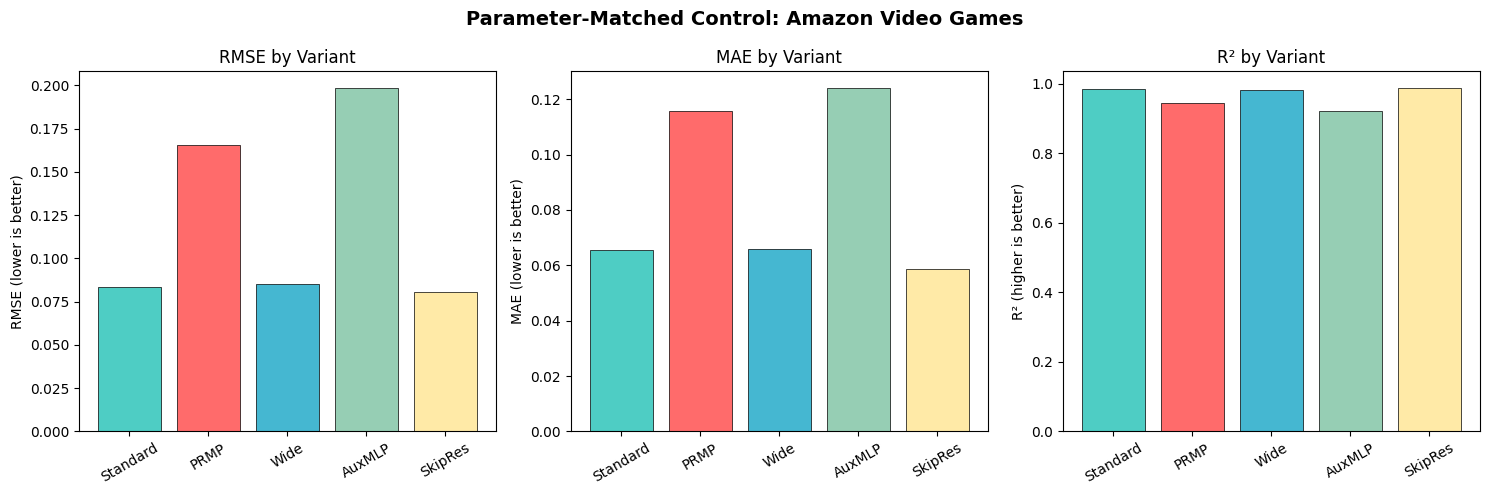

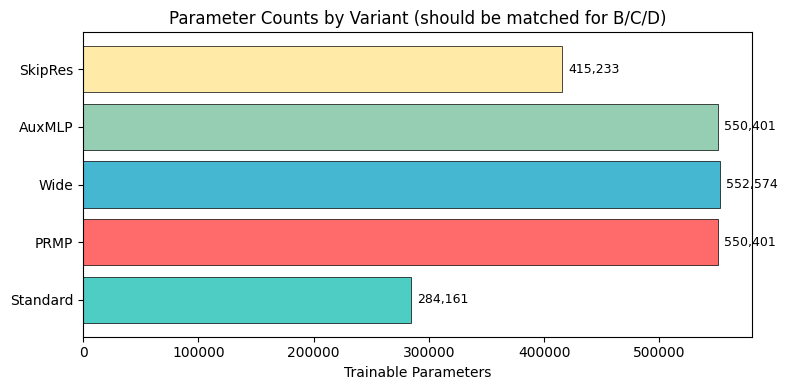


Total runtime: 52.7s


In [13]:
# ── Results Summary Table ──
print(f"{'Variant':<22} {'Params':>10} {'RMSE':>10} {'MAE':>10} {'R2':>10}")
print("-" * 66)
for vname in all_results:
    for seed in SEEDS:
        if seed in all_results[vname]:
            m = all_results[vname][seed]
            print(f"{vname:<22} {m['param_count']:>10,d} {m['rmse']:>10.4f} {m['mae']:>10.4f} {m['r2']:>10.4f}")

# ── Bar Chart: RMSE comparison ──
variant_names = list(all_results.keys())
short_names = ["Standard", "PRMP", "Wide", "AuxMLP", "SkipRes"]
rmse_means = []
for vname in variant_names:
    vals = [all_results[vname][s]['rmse'] for s in SEEDS if s in all_results[vname]]
    rmse_means.append(np.mean(vals))

colors = ['#4ECDC4', '#FF6B6B', '#45B7D1', '#96CEB4', '#FFEAA7']
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# RMSE
axes[0].bar(short_names, rmse_means, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_ylabel('RMSE (lower is better)')
axes[0].set_title('RMSE by Variant')
axes[0].tick_params(axis='x', rotation=30)

# MAE
mae_means = []
for vname in variant_names:
    vals = [all_results[vname][s]['mae'] for s in SEEDS if s in all_results[vname]]
    mae_means.append(np.mean(vals))
axes[1].bar(short_names, mae_means, color=colors, edgecolor='black', linewidth=0.5)
axes[1].set_ylabel('MAE (lower is better)')
axes[1].set_title('MAE by Variant')
axes[1].tick_params(axis='x', rotation=30)

# R2
r2_means = []
for vname in variant_names:
    vals = [all_results[vname][s]['r2'] for s in SEEDS if s in all_results[vname]]
    r2_means.append(np.mean(vals))
axes[2].bar(short_names, r2_means, color=colors, edgecolor='black', linewidth=0.5)
axes[2].set_ylabel('R² (higher is better)')
axes[2].set_title('R² by Variant')
axes[2].tick_params(axis='x', rotation=30)

plt.suptitle('Parameter-Matched Control: Amazon Video Games', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

# ── Parameter count comparison ──
fig2, ax2 = plt.subplots(figsize=(8, 4))
param_counts = [all_results[vname][SEEDS[0]]['param_count'] for vname in variant_names]
ax2.barh(short_names, param_counts, color=colors, edgecolor='black', linewidth=0.5)
ax2.set_xlabel('Trainable Parameters')
ax2.set_title('Parameter Counts by Variant (should be matched for B/C/D)')
for i, (name, count) in enumerate(zip(short_names, param_counts)):
    ax2.text(count + max(param_counts)*0.01, i, f'{count:,d}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print(f"\nTotal runtime: {total_time:.1f}s")